In [3]:
import numpy as np
import matplotlib.pyplot as plt

def t_on_rectangle_boundary(x, y, width, height):
    """
    Map near-boundary point (x,y) to t in [0,1), clockwise from top-center.
    (t=0 at (0, +height/2).)
    """
    w, h = width, height
    xL, xR = -w/2,  w/2
    yB, yT = -h/2,  h/2
    P = 2*(w + h)

    d_top    = np.abs(y - yT)
    d_right  = np.abs(x - xR)
    d_bottom = np.abs(y - yB)
    d_left   = np.abs(x - xL)
    side = np.argmin(np.column_stack([d_top, d_right, d_bottom, d_left]), axis=1)

    s = np.zeros_like(x, dtype=float)

    # Top edge: start at (0,yT), move to the right (clockwise)
    m = (side == 0)
    xt = x[m]
    dist_top = np.where(xt >= 0, xt, w - xt)
    s[m] = dist_top

    # Right edge: after reaching (xR,yT), go down
    m = (side == 1)
    s[m] = (w/2) + (yT - y[m])

    # Bottom edge: then go left
    m = (side == 2)
    s[m] = (w/2) + h + (xR - x[m])

    # Left edge: then go up
    m = (side == 3)
    s[m] = (w/2) + h + w + (y[m] - yB)

    t = np.mod(s, P) / P
    return t


def rectangle_boundary_points_and_normals(width, height, n_w=120, n_h=60):
    """
    Return boundary points around a rectangle and outward normals at those points.

    We allow different numbers of points on the horizontal (n_w) and vertical (n_h)
    sides so students can tune the *density* of boundary charges.

    Output:
      pts:    (N,2) boundary locations
      nhat:   (N,2) outward unit normals at each point
      ds_arr: (N,)  segment length represented by each boundary point (used to make q = σ ds)
    """
    w, h = float(width), float(height)
    xL, xR = -w/2, w/2
    yB, yT = -h/2, h/2

    n_w = int(n_w)
    n_h = int(n_h)
    if n_w < 4 or n_h < 4:
        raise ValueError("Need at least 4 points per side.")

    # Use midpoints so we never land exactly on corners (corner normals are ambiguous).
    def midpoints(a, b, N):
        edges = np.linspace(a, b, N+1)
        return 0.5*(edges[:-1] + edges[1:])

    # Top edge (left -> right)
    top_x = midpoints(xL, xR, n_w)
    top_y = np.full_like(top_x, yT)
    top_pts = np.column_stack([top_x, top_y])
    top_n = np.tile([0.0, 1.0], (len(top_pts), 1))
    top_ds = np.full(len(top_pts), w / n_w)

    # Right edge (top -> bottom)
    right_y = midpoints(yT, yB, n_h)
    right_x = np.full_like(right_y, xR)
    right_pts = np.column_stack([right_x, right_y])
    right_n = np.tile([1.0, 0.0], (len(right_pts), 1))
    right_ds = np.full(len(right_pts), h / n_h)

    # Bottom edge (right -> left)
    bottom_x = midpoints(xR, xL, n_w)
    bottom_y = np.full_like(bottom_x, yB)
    bottom_pts = np.column_stack([bottom_x, bottom_y])
    bottom_n = np.tile([0.0, -1.0], (len(bottom_pts), 1))
    bottom_ds = np.full(len(bottom_pts), w / n_w)

    # Left edge (bottom -> top)
    left_y = midpoints(yB, yT, n_h)
    left_x = np.full_like(left_y, xL)
    left_pts = np.column_stack([left_x, left_y])
    left_n = np.tile([-1.0, 0.0], (len(left_pts), 1))
    left_ds = np.full(len(left_pts), h / n_h)

    pts = np.vstack([top_pts, right_pts, bottom_pts, left_pts])
    nhat = np.vstack([top_n, right_n, bottom_n, left_n])
    ds_arr = np.concatenate([top_ds, right_ds, bottom_ds, left_ds])

    return pts, nhat, ds_arr


def slab_normals_at_points(pts, width, height):
    """
    Return an outward unit normal nhat at each point by choosing the nearest slab face.
    This makes E_perp/E_parallel work automatically for different slice directions.

    For points near the top/bottom faces, nhat is ±y.
    For points near the left/right faces, nhat is ±x.
    """
    x, y = pts[:, 0], pts[:, 1]
    w, h = float(width), float(height)
    xL, xR = -w/2, w/2
    yB, yT = -h/2, h/2

    d_top = np.abs(y - yT)
    d_right = np.abs(x - xR)
    d_bottom = np.abs(y - yB)
    d_left = np.abs(x - xL)

    side = np.argmin(np.column_stack([d_top, d_right, d_bottom, d_left]), axis=1)

    nhat = np.zeros_like(pts)
    nhat[side == 0] = [0.0,  1.0]   # top
    nhat[side == 1] = [1.0,  0.0]   # right
    nhat[side == 2] = [0.0, -1.0]   # bottom
    nhat[side == 3] = [-1.0, 0.0]   # left
    return nhat


def decompose_E(Ex, Ey, nhat):
    """
    Decompose E into components relative to a SINGLE reference normal nhat.

    Inputs:
      Ex, Ey: arrays of shape (N,)  (field components along the path)
      nhat:   array-like of shape (2,)  (reference normal direction)

    Returns:
      E_perp: array (N,) = E · n_hat
      E_par:  array (N,) = E · t_hat, where t_hat is n rotated +90°: (-ny, nx)
    """
    nhat = np.asarray(nhat, dtype=float).reshape(2,)
    n_norm = np.hypot(nhat[0], nhat[1])
    if n_norm == 0:
        raise ValueError("nhat must be nonzero.")
    nx, ny = nhat / n_norm

    # Tangent direction (right-hand rotation of n)
    tx, ty = -ny, nx

    Ex = np.asarray(Ex, dtype=float)
    Ey = np.asarray(Ey, dtype=float)

    E_perp = Ex*nx + Ey*ny
    E_par  = Ex*tx + Ey*ty
    return E_perp, E_par

def bound_surface_charges_from_P_rectangle(width, height, P_vec, n_w=120, n_h=60):
    """
    Build discrete bound charges on the boundary using:
        sigma_b = P · n

    We discretize each boundary point as representing a small segment ds, so:
        q_i = sigma_i * ds_i

    n_w = number of points on top/bottom edges
    n_h = number of points on left/right edges
    """
    pts, nhat, ds_arr = rectangle_boundary_points_and_normals(width, height, n_w=n_w, n_h=n_h)
    P = np.array(P_vec, dtype=float)
    sigma = nhat @ P
    q = sigma * ds_arr
    return pts, q


def bound_surface_charges_from_P_rectangle(width, height, P_vec, n_w=120, n_h=60):
    """
    Build discrete bound charges on the boundary using:
        sigma_b = P · n

    We discretize each boundary point as representing a small segment ds, so:
        q_i = sigma_i * ds_i

    n_w = number of points on top/bottom edges
    n_h = number of points on left/right edges
    """
    pts, nhat, ds_arr = rectangle_boundary_points_and_normals(width, height, n_w=n_w, n_h=n_h)
    P = np.array(P_vec, dtype=float)
    sigma = nhat @ P
    q = sigma * ds_arr
    return pts, q


def first_surface_normal_from_path(path_pts, width, height, eps=1e-12):
    """
    Returns a single outward unit normal vector n_ref (shape (2,))
    based on the FIRST slab boundary the student's path intersects.

    Assumes the slab is the rectangle:
      x in [-width/2, +width/2], y in [-height/2, +height/2].

    Works best when the path starts inside the slab and goes outward,
    but it also handles outside->inside; it chooses the first boundary crossing
    along the path direction.
    """
    xL, xR = -width/2, width/2
    yB, yT = -height/2, height/2

    def inside(p):
        return (xL <= p[0] <= xR) and (yB <= p[1] <= yT)

    # Determine whether we start inside or outside
    start_inside = inside(path_pts[0])

    # Walk segments and find first crossing
    for i in range(len(path_pts) - 1):
        p0 = path_pts[i]
        p1 = path_pts[i + 1]

        in0 = inside(p0)
        in1 = inside(p1)

        # We look for a change in inside/outside state → boundary crossing
        if in0 == in1:
            continue

        # Segment param: p(t) = p0 + t*(p1-p0), t in [0,1]
        d = p1 - p0

        candidates = []

        # Intersect with vertical lines x = xL or xR
        if abs(d[0]) > eps:
            tL = (xL - p0[0]) / d[0]
            y_at_tL = p0[1] + tL * d[1]
            if 0.0 <= tL <= 1.0 and (yB - eps) <= y_at_tL <= (yT + eps):
                candidates.append((tL, np.array([-1.0, 0.0])))  # left face normal

            tR = (xR - p0[0]) / d[0]
            y_at_tR = p0[1] + tR * d[1]
            if 0.0 <= tR <= 1.0 and (yB - eps) <= y_at_tR <= (yT + eps):
                candidates.append((tR, np.array([1.0, 0.0])))   # right face normal

        # Intersect with horizontal lines y = yB or yT
        if abs(d[1]) > eps:
            tB = (yB - p0[1]) / d[1]
            x_at_tB = p0[0] + tB * d[0]
            if 0.0 <= tB <= 1.0 and (xL - eps) <= x_at_tB <= (xR + eps):
                candidates.append((tB, np.array([0.0, -1.0])))  # bottom face normal

            tT = (yT - p0[1]) / d[1]
            x_at_tT = p0[0] + tT * d[0]
            if 0.0 <= tT <= 1.0 and (xL - eps) <= x_at_tT <= (xR + eps):
                candidates.append((tT, np.array([0.0, 1.0])))   # top face normal

        if not candidates:
            # Shouldn't happen often; fall back to nearest-face normal at p0
            return nearest_face_normal(p0, width, height)

        # Choose earliest intersection along this segment
        t_hit, n_face = min(candidates, key=lambda z: z[0])

        # If we started outside and entered, "outward" normal should still be outward
        # (the face normal defined above is always outward).
        return n_face

    # If no crossing was found, fall back: choose nearest face to the first point
    return nearest_face_normal(path_pts[0], width, height)


def nearest_face_normal(p, width, height):
    """Fallback: outward normal of the closest face to point p."""
    x, y = p
    xL, xR = -width/2, width/2
    yB, yT = -height/2, height/2
    d = np.array([abs(y - yT), abs(x - xR), abs(y - yB), abs(x - xL)])
    k = np.argmin(d)
    return [np.array([0.0,  1.0]),
            np.array([1.0,  0.0]),
            np.array([0.0, -1.0]),
            np.array([-1.0, 0.0])][k]




In [4]:
# ==========================================================
# STUDENTS: READ THIS CELL TOP-TO-BOTTOM
#
# Four panels:
# (a) Bound charges from σ_b = P·n
# (b) Field from bound charges ONLY
# (c) Applied (external) uniform field
# (d) Total field = applied + bound-charge field
#
# MAIN KNOBS:
#   E_app              (line ~27)
#   alpha              (line ~39)
#   points_per_length  (line ~49)   <-- NEW: charge density along the boundary
# ==========================================================

# -----------------------------
# 1) Slab geometry
# -----------------------------
width = 2.0
height = 1.0

# -----------------------------
# 2) Applied electric field (students change this)
# -----------------------------
# Try: (1,0), (0,1), (1,1)
E_app = np.array([1.0, 0.0], dtype=float)

# -----------------------------
# 3) Simple polarization model
# -----------------------------
alpha = 0.2
P_vec = alpha * E_app

# -----------------------------
# 4) Make boundary charges from sigma_b = P · n
# -----------------------------
# NEW: students can tune the *density* of boundary charges
# (points per unit length along the boundary)
points_per_length = 80   # try 30, 80, 150

n_w = max(20, int(points_per_length * width))    # top/bottom
n_h = max(20, int(points_per_length * height))   # left/right

charges_position, charges_q = bound_surface_charges_from_P_rectangle(
    width=width, height=height, P_vec=P_vec, n_w=n_w, n_h=n_h
)

# -----------------------------
# 5) Field grid + numerical settings
# -----------------------------
pad = 0.8
xmin, xmax = -width/2 - pad,  width/2 + pad
ymin, ymax = -height/2 - pad, height/2 + pad

nx, ny = 55, 55
softening = 0.04
eps = 1e-12

X, Y, eval_pts = make_field_grid(xmin, xmax, ymin, ymax, nx=nx, ny=ny)

# ==========================================================
# Compute fields on the 2D grid
# ==========================================================

# (b) Field from bound charges only
Ex_b, Ey_b = electric_field_from_point_charges(
    eval_pts, charges_position, charges_q, softening=softening
)

# (c) Applied field everywhere
Ex_app = np.full_like(Ex_b, E_app[0])
Ey_app = np.full_like(Ey_b, E_app[1])

# (d) Total field
Ex_tot = Ex_b + Ex_app
Ey_tot = Ey_b + Ey_app

# reshape for plotting
Ex_b = Ex_b.reshape(X.shape)
Ey_b = Ey_b.reshape(Y.shape)
Ex_app = Ex_app.reshape(X.shape)
Ey_app = Ey_app.reshape(Y.shape)
Ex_tot = Ex_tot.reshape(X.shape)
Ey_tot = Ey_tot.reshape(Y.shape)

# magnitudes
E_b_mag = np.sqrt(Ex_b**2 + Ey_b**2)
E_app_mag = np.sqrt(Ex_app**2 + Ey_app**2)
E_tot_mag = np.sqrt(Ex_tot**2 + Ey_tot**2)

# unit vectors
Ub_x = Ex_b / (E_b_mag + eps)
Ub_y = Ey_b / (E_b_mag + eps)

Ua_x = Ex_app / (E_app_mag + eps)
Ua_y = Ey_app / (E_app_mag + eps)

Ut_x = Ex_tot / (E_tot_mag + eps)
Ut_y = Ey_tot / (E_tot_mag + eps)

# ==========================================================
# Four-panel figure
# ==========================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
(axA, axB), (axC, axD) = axes

# ---- QUIVER SETTINGS (STUDENTS CAN IGNORE) ----
skip = 3        # larger number = fewer arrows
qscale = 35     # larger number = smaller arrows

# ---- COLOR SCHEME ------------------------------
cmap = "Blues"

# ==========================================================
# COMMON COLOR SCALE FOR ALL FIELD PLOTS
# ==========================================================
logEb = np.log10(E_b_mag + eps)
logEa = np.log10(E_app_mag + eps)
logEt = np.log10(E_tot_mag + eps)

vmin = min(logEb.min(), logEa.min(), logEt.min())
vmax = max(logEb.max(), logEa.max(), logEt.max())

# ----------------------------------------------------------
# (a) Bound charges + path overlay
# ----------------------------------------------------------
axA.plot([-width/2, width/2, width/2, -width/2, -width/2],
         [-height/2, -height/2, height/2, height/2, -height/2],
         linewidth=2)

plus = charges_q > 0
minus = charges_q < 0

axA.scatter(charges_position[plus, 0],  charges_position[plus, 1],  s=18, label="+ (σ_b)")
axA.scatter(charges_position[minus, 0], charges_position[minus, 1], s=18, label="- (σ_b)")


# mark t=0 and +t direction on the boundary (parameterization tool)
t0_x, t0_y = 0.0, height/2
axA.scatter([t0_x], [t0_y], s=70, zorder=5, color="black")
axA.annotate("", xy=(t0_x + 0.35*width, t0_y),
             xytext=(t0_x, t0_y),
             arrowprops=dict(arrowstyle="->", linewidth=2))
axA.text(t0_x + 0.18*width, t0_y + 0.05*height, "t",
         ha="center", va="bottom")

axA.set_aspect("equal", "box")
axA.set_xlim(xmin, xmax)
axA.set_ylim(ymin, ymax)
axA.set_title("(a) Bound surface charge")
axA.legend(frameon=False, loc="upper right")

# ----------------------------------------------------------
# (b) Field from bound charges only
# ----------------------------------------------------------
contB = axB.contourf(X, Y, np.log10(E_b_mag + eps),
                     levels=30, cmap=cmap,
                     vmin=vmin, vmax=vmax)

axB.quiver(X[::skip, ::skip], Y[::skip, ::skip],
           Ub_x[::skip, ::skip], Ub_y[::skip, ::skip],
           pivot="middle", scale=qscale)

axB.plot([-width/2, width/2, width/2, -width/2, -width/2],
         [-height/2, -height/2, height/2, height/2, -height/2],
         linewidth=2)

axB.set_aspect("equal", "box")
axB.set_xlim(xmin, xmax)
axB.set_ylim(ymin, ymax)
axB.set_title("(b) Field from bound charges only")

# ----------------------------------------------------------
# (c) Applied field only
# ----------------------------------------------------------
contC = axC.contourf(X, Y, np.log10(E_app_mag + eps),
                     levels=30, cmap=cmap,
                     vmin=vmin, vmax=vmax)

axC.quiver(X[::skip, ::skip], Y[::skip, ::skip],
           Ua_x[::skip, ::skip], Ua_y[::skip, ::skip],
           pivot="middle", scale=qscale)

axC.plot([-width/2, width/2, width/2, -width/2, -width/2],
         [-height/2, -height/2, height/2, height/2, -height/2],
         linewidth=2)

axC.set_aspect("equal", "box")
axC.set_xlim(xmin, xmax)
axC.set_ylim(ymin, ymax)
axC.set_title("(c) Applied field only")

# ----------------------------------------------------------
# (d) Total field
# ----------------------------------------------------------
contD = axD.contourf(X, Y, np.log10(E_tot_mag + eps),
                     levels=30, cmap=cmap,
                     vmin=vmin, vmax=vmax)

axD.quiver(X[::skip, ::skip], Y[::skip, ::skip],
           Ut_x[::skip, ::skip], Ut_y[::skip, ::skip],
           pivot="middle", scale=qscale)

axD.plot([-width/2, width/2, width/2, -width/2, -width/2],
         [-height/2, -height/2, height/2, height/2, -height/2],
         linewidth=2)

axD.set_aspect("equal", "box")
axD.set_xlim(xmin, xmax)
axD.set_ylim(ymin, ymax)
axD.set_title("(d) Total field = applied + bound")

plt.tight_layout()
plt.show()


NameError: name 'make_field_grid' is not defined

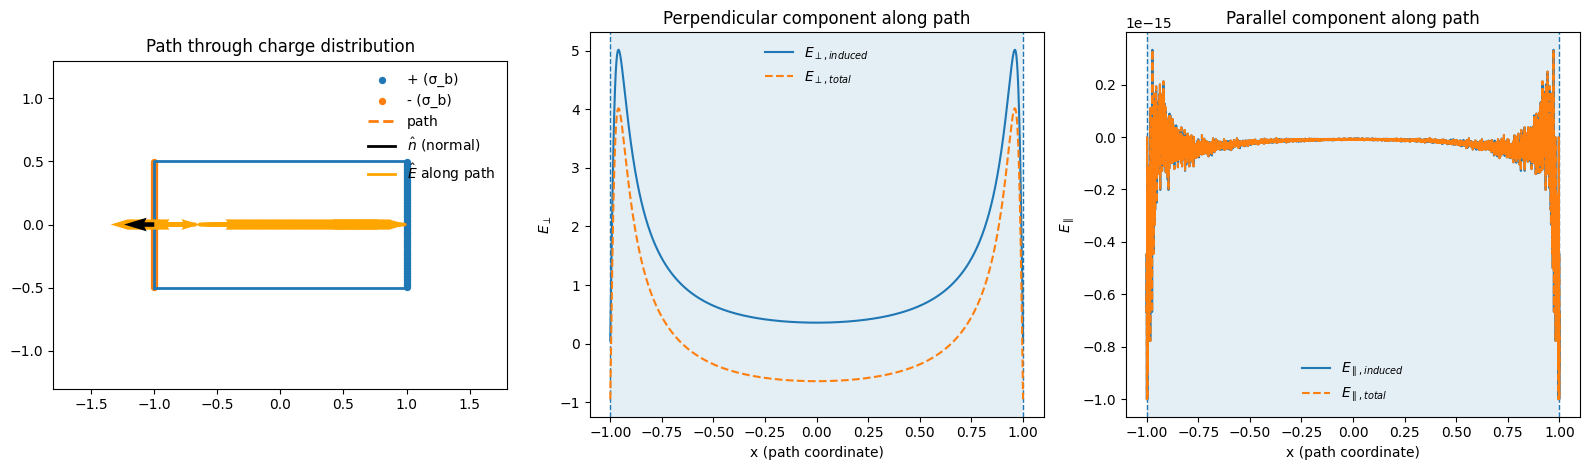

Tip: change the path definition in the cell above (e.g., slice along x at y=0).  E_perp/E_parallel update automatically.


In [ ]:
# ==========================================================
# Boundary-condition slice along the path (defined in the cell above)
#
#   - We show the path we're walking alongside the E_perp and E_parallel plots.
#   - We compute E_perp and E_parallel automatically:
#         E_perp = E · n
#         E_par  = E · t
#     where n is chosen by the nearest slab face at each point.
# ==========================================================

# Use the charges (charges_position, charges_q) from the previous cell
# ==========================================================
# Define the "walking path" we will use later for boundary-condition plots
# We'll overlay it on panel (a).
# (Here: slice along the y-axis through the middle: x = 0.)
# ==========================================================
num_points_path = 5000
min_line = -1
max_line =  1
fixed_value = 0.0
changing_values = np.linspace(min_line, max_line, num_points_path)
fixed_values = np.full_like(changing_values, fixed_value)

# CHANGE THIS LINE TO CHOOSE A DIFFERENT PATH
# To walk along horizontally, use np.column_stack([changing_values, fixed_values])
# To walk along vertically, use   np.column_stack([fixed_values, changing_values])
path_pts = np.column_stack([changing_values, fixed_values])

# ----------------------------------------------------------
# Compute fields along the path
# ----------------------------------------------------------
Ex_b_path, Ey_b_path = electric_field_from_point_charges(
    path_pts, charges_position, charges_q, softening=softening
)

Ex_t_path = Ex_b_path + E_app[0]
Ey_t_path = Ey_b_path + E_app[1]

# ---- Make unit vectors of the TOTAL field along the path ----
E_mag = np.sqrt(Ex_t_path**2 + Ey_t_path**2) + 1e-12   # avoid divide-by-zero
Ux = Ex_t_path / E_mag
Uy = Ey_t_path / E_mag

# ----------------------------------------------------------
# Automatic perpendicular / parallel decomposition
# ----------------------------------------------------------
n_ref = first_surface_normal_from_path(path_pts, width, height)

Eperp_b, Epar_b = decompose_E(Ex_b_path, Ey_b_path, n_ref)
Eperp_t, Epar_t = decompose_E(Ex_t_path, Ey_t_path, n_ref)

# ----------------------------------------------------------
# Plot: path + components along the path (1 x 3 layout)
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
ax0, ax1, ax2 = axes

# ----------------------------------------------------------
# Identify which coordinate is changing (x or y) so we can:
#   - use the right "path coordinate" for plots
#   - shade/mark the correct slab extent automatically
# ----------------------------------------------------------
dx = np.ptp(path_pts[:, 0])   # peak-to-peak range
dy = np.ptp(path_pts[:, 1])

if dy >= dx:
    # varying in y (vertical path)
    s = path_pts[:, 1]
    half_extent = height / 2
    coord_label = "y"
else:
    # varying in x (horizontal path)
    s = path_pts[:, 0]
    half_extent = width / 2
    coord_label = "x"

# ---- Panel (1): charge distribution with the path overlaid ----
ax0.plot([-width/2, width/2, width/2, -width/2, -width/2],
         [-height/2, -height/2, height/2, height/2, -height/2],
         linewidth=2)

plus = charges_q > 0
minus = charges_q < 0
ax0.scatter(charges_position[plus, 0],  charges_position[plus, 1],  s=18, label="+ (σ_b)")
ax0.scatter(charges_position[minus, 0], charges_position[minus, 1], s=18, label="- (σ_b)")

# overlay the walk path
ax0.plot(path_pts[:, 0], path_pts[:, 1], linewidth=2, linestyle="--", label="path")

ax0.set_aspect("equal", "box")
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymin, ymax)
ax0.set_title("Path through charge distribution")

# show the normal vector we're using for E parallel and E perpendicular
ax0.quiver(path_pts[0,0], path_pts[0,1],
           n_ref[0], n_ref[1],
           scale=15,       # smaller number = bigger arrow
           width=0.01,
           color="black",
           zorder=10)

# show the electric field direction along the path
step = 35
ax0.quiver(
    path_pts[::step, 0],
    path_pts[::step, 1],
    Ux[::step],
    Uy[::step],
    scale=10,        # tune size (smaller = bigger arrows)
    width=0.008,
    color="orange",
    zorder=9
)

# Legend proxies for vector arrows
ax0.plot([], [], color="black",  linewidth=2, label=r"$\hat n$ (normal)")
ax0.plot([], [], color="orange", linewidth=2, label=r"$\hat E$ along path")
ax0.legend(frameon=False, loc="upper right")


# ---- Panel (2): E_perp along the path ----
# Panel 2: use half_extent and s, and dynamic label
ax1.axvline(-half_extent, linestyle="--", linewidth=1)
ax1.axvline(+half_extent, linestyle="--", linewidth=1)
ax1.axvspan(-half_extent, +half_extent, alpha=0.12)

ax1.plot(s, Eperp_b,  label=r"$E_{\perp, induced}$")
ax1.plot(s, Eperp_t, "--", label=r"$E_{\perp, total}$")
ax1.set_xlabel(f"{coord_label} (path coordinate)")
ax1.set_ylabel(r"$E_\perp$")
ax1.set_title(r"Perpendicular component along path")
ax1.legend(frameon=False)

# ---- Panel (3): E_parallel along the path ----
ax2.axvline(-half_extent, linestyle="--", linewidth=1)
ax2.axvline(+half_extent, linestyle="--", linewidth=1)
ax2.axvspan(-half_extent, +half_extent, alpha=0.12)

ax2.plot(s, Epar_b,  label=r"$E_{\parallel, induced}$")
ax2.plot(s, Epar_t, "--", label=r"$E_{\parallel, total}$")
ax2.set_xlabel(f"{coord_label} (path coordinate)")
ax2.set_ylabel(r"$E_\parallel$")
ax2.set_title(r"Parallel component along path")
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

print("Tip: change the path definition in the cell above (e.g., slice along x at y=0).  E_perp/E_parallel update automatically.")
